# עבודה בלמידת מכונה — סיווג סנטימנט של ציוצים בטוויטר

**סוג הבעיה:** סיווג רב-מחלקתי (Multi-class Classification) לארבע מחלקות — `Positive` / `Negative` / `Neutral` / `Irrelevant`

**אלגוריתם הלמידה:** Multinomial Naive Bayes במימוש עצמאי (חלק 3), מאומת מול המימוש של `scikit-learn`

**מדד האיכות:** Macro-Average F1 — המדד שההנחיות מחייבות בבעיית סיווג רב-מחלקתית שאין בה מחלקה מרכזית אחת

**הנתונים:** `twitter_training.csv` כ-Train ו-`twitter_validation.csv` כ-Test, בדיוק כפי שסופקו — **ללא חלוקה מחדש**

---

### פרטי המגישים

| שם פרטי ואות ראשונה של שם המשפחה | 4 ספרות אחרונות של ת.ז. |
|---|---|
| רוי אופנשטיין | 1978 |
| איתי מלכה | 2891 |
| שון איגורוב | 9578 |

---

### שימוש בכלי בינה מלאכותית (AI Chatbot Prompts)

| # | הכלי | הפרומפט / המטרה | מה עשינו עם הפלט |
|---|---|---|---|
| 1 | Gemini | לכתוב את הקוד של המטלה | שמנו אותו במנוע נוסף על מנת לשפר את הקוד |
| 2 |  Claude | לשפר את הקוד של המטלה ולעשות תיקונים | שמנו אותו במטלה, ערכנו בו שינויים קטנים על מנת לצמצם קוד לא רלוונטי ולשפר |
| 3 |  Gemini, Claude | הסברים פשוטים על הקוד שנכתב | להבין את הקוד שנכתב לעומק, על מנת לכתוב הסברים לקוד במילים, הן לקובץ והן לסרטון שלנו |


## חלק 1 — הקדמה, הצגת הנתונים וטעינה

**הסבר הבעיה**

 נתון טקסט של ציוץ מטוויטר שנאסף עבור ישות מסוימת (כלומר, לדוגמה, חברה מסוימת, משחק מסוים ועוד) ואנחנו רוצים לסווג אותו להחליט מהו אופיו של הציוץ - האם המצייץ של הציוץ רואה את הישות בצורה חיובית? האם בצורה שלילית? לשם כך נסווג כל ציוץ לאחת מארבע קטגוריות:

* **Positive** — הציוץ מביע יחס חיובי כלפי הישות
* **Negative** — הציוץ מביע יחס שלילי כלפי הישות
* **Neutral** — הציוץ מדבר על הישות אך לא מביע דעה חד משמעית לכאן או לכאן
* **Irrelevant** — הציוץ נאסף תחת ישות ספציפית, אבל הוא לא באמת מדבר עליה

**מה עושים בשלב הזה?**

 אנחנו מבצעים טעינה של הנתונים שיש לנו מהקאגל קודם כל. לשם כך אנחנו טוענים את שני קבצי ה-CSV למבנה הנתונים DataFrame — טבלה עם שורות ועמודות, בדיוק כמו גיליון אקסל. לעמודות בקבצים שהשגנו מהקאגל אין כותרות (Header), ולכן אנחנו מעבירים `header=None` ונותנים לעמודות שמות בעצמנו.
 בנוסף לכך, אנחנו מבצעים ייבוא של ספריות והגדרות גלובליות שיעזרו לנו במסגרת הפרויקט הזה.

 לאחר שביצענו טעינה וייבאנו ספריות, נדפיס את חמשת השורות הראשונות בכל קובץ, כמו שהתבקשנו במטלה זו, בעזרת הפקודה head שמבצעת בצורה דיפולטיבית הדפסה של חמשת השורות הראשונות.

In [73]:
# ============================================================================ #
#  ייבוא ספריות והגדרות גלובליות                                              #
# ============================================================================ #
import ast
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.naive_bayes import MultinomialNB   # ONLY to verify our own implementation

RANDOM_STATE = 42
CLASS_ORDER = ["Negative", "Neutral", "Positive", "Irrelevant"]

In [74]:
# ============================================================================ #
#  טעינת הנתונים                                                              #
# ============================================================================ #
COLUMNS = ["Tweet_ID", "Entity", "Sentiment", "Tweet_Text"]

train_df = pd.read_csv("twitter_training.csv",   names=COLUMNS, header=None)
test_df  = pd.read_csv("twitter_validation.csv", names=COLUMNS, header=None)

print(f"Train set : {train_df.shape[0]:,} rows x {train_df.shape[1]} columns")
print(f"Test  set : {test_df.shape[0]:,} rows x {test_df.shape[1]} columns")

Train set : 74,682 rows x 4 columns
Test  set : 1,000 rows x 4 columns


In [75]:
# Required by the assignment: the first 5 rows of the TRAIN set
train_df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [76]:
# Required by the assignment: the first 5 rows of the TEST set
test_df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


## חלק 2 — ניקוי הנתונים והנדסת מאפיינים (Feature Engineering)

חלק זה של העבודה מתחלק לשני חלקים:

**1. ניקוי טקסט — פעולה שמתבצעת על כל שורה בנפרד.**

 הפונקציה מקבלת ציוץ מהטבלה שלנו ומחזירה ציוץ מנוקה, בלי לדעת שום דבר על שאר הציוצים האחרים בטבלה שלנו. לכן מותר להפעיל אותה על ה-Train ועל ה-Test באותה מידה, ואין בכך שום דליפת מידע שתשפיע על הנתונים שלנו.

**2. ייצוג מספרי (Vectorization) — פעולה שלומדת פרמטרים מהנתונים.**

 בניית אוצר המילים (Vocabulary) ומשקלי ה-IDF הן פעולות שרואות את *כל* הטבלה שלנו. לכן חייבים לבצע `fit` על ה-Train **בלבד**, ועל ה-Test לבצע רק `transform`. אם נלמד את אוצר המילים גם מה-Test, המודל "יציץ" בנתוני המבחן — וזה בדיוק מה שנקרא Data Leakage.

### מה בדיוק מנקים ולמה?

| הפעולה | הסיבה |
|---|---|
| הסרת שורות ללא טקסט | אי אפשר להסיק מסקנות לגבי הסיווג שלנו מטקסט שלא קיים |
| המרה לאותיות קטנות (Lowercasing) | `Good` ו-`good` הן אותה מילה. בלי זה הן שני מאפיינים נפרדים והמודל לומד כל אחד מהם בנפרד - דבר זה לא נכון וישפיע לרעה על תוצאות המודל |
| הסרת קישורים (URLs) | קישור הוא מזהה ייחודי ולא עוזר לנו להבין יותר מדי את סיווג הציוץ, ולכן הוא לא יכול ללמד את המודל כלום. הוא מיותר מסיבה זו ולכן נסיר אותו |
| הסרת תיוגים (`@user`) | התיוג הוא שם משתמש בטוויטר של מישהו. הוא לא עוזר לנו להבין את סיווג הציוץ כלל ולכן נסיר אותו |
| הסרת מספרים, סימני פיסוק ותווים מיוחדים | משאירים אותיות בלבד, כדי שאוצר המילים שנרכיב מהציוצים יכיל מילים בלבד שניתן להבין מהם את סיווג הציוץ |
| כיווץ רווחים כפולים | ניקיון טכני לפני הפירוק למילים (Tokenization) |


**הערה:**

 אנחנו מחליפים כל דבר שאנו מסירים מהציוץ ב**רווח** ולא במחרוזת ריקה. אחרת זה יכול לגרום לבעיות כמו ש `"great!Awful"` היה הופך למילה אחת ושגויה `greatawful`.

In [77]:
# ============================================================================ #
#  חלק 2א: ניקוי הטקסט                                                        #
# ============================================================================ #
URL_RE = re.compile(r"https?://\S+|www\.\S+|(?:\b[\w-]+\.)+(?:com|org|net|co|ly)/\S+")
MENTION_RE = re.compile(r"@\w+")
NONALPHA_RE = re.compile(r"[^a-z\s]")
SPACES_RE = re.compile(r"\s+")


def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()                        # 1. אותיות קטנות
    text = URL_RE.sub(" ", text)               # 2. הורדת קישורים
    text = MENTION_RE.sub(" ", text)           # 3. הורדת תיוגים
    text = re.sub(r"n't\b", " not", text)
    text = re.sub(r"'s\b", "", text)
    text = NONALPHA_RE.sub(" ", text)          # 4. הורדת כל מה שהוא לא אותיות
    text = SPACES_RE.sub(" ", text).strip()    # 5. צמצום רווחים
    return text


# ----------------------------- הסרת שורות ללא טקסט -------------------------------------------- #
# הערה: אנחנו מסירים שורות מקובץ האימון בלבד ולא מקובץ הטסט
n_before = len(train_df)
train_df = train_df.dropna(subset=["Tweet_Text"]).reset_index(drop=True)

train_df["Clean_Text"] = train_df["Tweet_Text"].apply(clean_tweet)
test_df["Clean_Text"]  = test_df["Tweet_Text"].apply(clean_tweet)

# כאן מתבצעת הסרת השורות מקובץ האימון בלבד בפועל. כמו שנרשם מעלה - מתבצעת הסרה מקובץ האימון בלבד
train_df = train_df[train_df["Clean_Text"].str.len() > 0].reset_index(drop=True)

train_df["Clean_Text"] = train_df["Entity"].astype(str).str.lower() + " " + train_df["Clean_Text"]
test_df["Clean_Text"]  = test_df["Entity"].astype(str).str.lower() + " " + test_df["Clean_Text"]

print(f"Train : {n_before:,} -> {len(train_df):,} rows "
      f"({n_before - len(train_df):,} rows removed: empty or unusable text)")
print(f"Test  : {len(test_df):,} rows (untouched, as required for the final metric)")

Train : 74,682 -> 73,596 rows (1,086 rows removed: empty or unusable text)
Test  : 1,000 rows (untouched, as required for the final metric)


In [78]:
# ============================================================================ #
#  הדגמת ה-Feature Engineering על 3 דוגמאות מה-TRAIN                          #
# ============================================================================ #
def show_cleaning(df, name, patterns):
    """Show real rows that actually exercise the cleaning rules - not cherry-picked."""
    print("=" * 100)
    print(f"BEFORE / AFTER CLEANING  —  3 examples from the {name} set")
    print("=" * 100)
    for pat in patterns:
        hit = df[df["Tweet_Text"].str.contains(pat, case=False, na=False, regex=True)]
        if len(hit) == 0:
            continue
        row = hit.iloc[0]
        print(f"\n[matched rule: {pat}]  gold label = {row['Sentiment']}")
        print(f"  BEFORE : {row['Tweet_Text'][:300]}")
        print(f"  AFTER  : {row['Clean_Text'][:300]}")


PATTERNS = [r"http|www\.", r"@\w+", r"[0-9]{2,}|!{2,}"]
show_cleaning(train_df, "TRAIN", PATTERNS)

BEFORE / AFTER CLEANING  —  3 examples from the TRAIN set

[matched rule: http|www\.]  gold label = Neutral
  BEFORE : Modern Warfare For $38, Borderlands 3 For $20, And More Great Game Deals (PS4, Xbox One, Switch) unsorted.co/modern-warfare… https://t.co/2n68qoJKhU
  AFTER  : borderlands modern warfare for borderlands for and more great game deals ps xbox one switch

[matched rule: @\w+]  gold label = Positive
  BEFORE : So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg
  AFTER  : borderlands so i spent a few hours making something for fun if you do not know i am a huge fan and maya is one of my favorite characters so i decided to make myself a wallpaper for my pc here is the original image versus the creation i made enjoy

[matched rule: [0-9]{2,}|!{

In [79]:
# ============================================================================ #
#  אותה הדגמה על 3 דוגמאות מה-TEST (דרישת סעיף 2)                             #
# ============================================================================ #
show_cleaning(test_df, "TEST", PATTERNS)

BEFORE / AFTER CLEANING  —  3 examples from the TEST set

[matched rule: http|www\.]  gold label = Neutral
  BEFORE : Solo Q and this freak is spinning as fast as he can to lower the FPS. 
I thought they took this bs out

@Rainbow6Game https://t.co/mlvHMu4qeZ
  AFTER  : tomclancysrainbowsix solo q and this freak is spinning as fast as he can to lower the fps i thought they took this bs out

[matched rule: @\w+]  gold label = Negative
  BEFORE : @Microsoft Why do I pay for WORD when it functions so poorly on my @SamsungUS Chromebook? 🙄
  AFTER  : microsoft why do i pay for word when it functions so poorly on my chromebook

[matched rule: [0-9]{2,}|!{2,}]  gold label = Neutral
  BEFORE : Now the President is slapping Americans in the face that he really did commit an unlawful act after his  acquittal! From Discover on Google vanityfair.com/news/2020/02/t…
  AFTER  : google now the president is slapping americans in the face that he really did commit an unlawful act after his acquittal fr

### החצי השני: הפיכת מילים למספרים

מודלים מתמטיים לא יודעים לקרוא מילים — הם יודעים לקרוא וקטורים של מספרים. לשם כך נשתמש ב- **Bag of Words**: נבנה אוצר מילים מכל המילים שהופיעו ב-Train, וכל ציוץ הופך לווקטור שאורכו כגודל אוצר המילים, שבו כל תא סופר כמה פעמים המילה הזו הופיעה בציוץ.

ישנם מספר משתנים שנבדוק מאוחר יותר, בחלק 6א, במי יותר משתלם לבדוק, במקום להחליט עליהם מראש. משתנים אלו הם:

**1. ספירה (Count) מול שקלול (TF-IDF).** ב-TF-IDF כל ספירה מוכפלת בפקטור שמעניש מילים שמופיעות כמעט בכל הציוצים ומתגמל מילים נדירות וממוקדות. הנוסחה של Multinomial Naive Bayes נגזרת מהנחה של **ספירות שלמות**, ולכן `CountVectorizer` הוא הייצוג ה"נכון" תיאורטית עבור המודל שלנו. בפועל TF-IDF לפעמים עובד טוב יותר, אז נבדוק את שניהם וניתן ל-Cross-Validation להכריע.

**2. Unigrams מול Bigrams.** `ngram_range=(1,1)` מסתכל על מילים בודדות בכל בדיקה שהוא מבצע. `(1,2)` מוסיף גם צמדי מילים עוקבים בקביעות. הצמדים הם דרך טובה שבה מודל יכול לתפוס שלילה: `not good` הוא מאפיין אחד, בעוד שבמודל של מילים בודדות המילה `good` תישאר חיובית.

**3. גודל אוצר המילים.** הפרמטר `max_features` שומר רק את N המילים השכיחות ביותר. הגבלה ל-5,000 מילים נשמעת טובה למקרה שלנו — היא מקטינה את המודל ומסננת מילים נדירות — אבל היא גם זורקת לפח בדיוק את המילים הנדירות והממוקדות שהן הסימן החזק ביותר לתוצאה שלנו. גם סעיף זה ייבדק בצורה תיאורטית בשלב זה ולא יוחלט מראש.

בנוסף אנחנו מסירים מילות עצירה באנגלית (`stop_words="english"`) — מילים כמו `the`, `is`, `at` שמופיעות כמעט בכל ציוץ ולא יעזרו למודל שלנו בתחקור הטקסט.

התוצאה היא **מטריצה דלילה (Sparse Matrix)**: בציוץ ממוצע יש כ-15 מילים מתוך אוצר של 5,000, כלומר יותר מ-99% מהתאים הם אפס. שמירה של מטריצה כזו בצורה רגילה הייתה תופסת גיגה-בייטים. פורמט CSR שומר רק את התאים שאינם אפס ובכך חוסך למחשב שלנו שמירה של זיכרון רב, ולכן נשתמש בו.

In [80]:
# ============================================================================ #
#  כמו שנכתב מעלה זוהי הולכת להיות הדגמה בלבד! ההדגמה תהיה בעזרת unigram ושימוש ב-CountVectorizer.           #
#  התוצר הסופי שייקבע במסגרת עבודה זו (מה שנשתמש בו במודל) ייקבע בשלב 6 א' בעת בדיקת ה-Grid Search.                  #
# ============================================================================ #
demo_vec = CountVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 1))

X_demo_train = demo_vec.fit_transform(train_df["Clean_Text"])   # fit + transform on TRAIN
X_demo_test  = demo_vec.transform(test_df["Clean_Text"])        # transform ONLY on TEST

print(f"Train feature matrix : {X_demo_train.shape}  "
      f"({X_demo_train.nnz / np.prod(X_demo_train.shape) * 100:.2f}% non-zero)")
print(f"Test  feature matrix : {X_demo_test.shape}")
print(f"Vocabulary size      : {len(demo_vec.get_feature_names_out()):,}")

# דוגמה לאיך ציוץ ספציפי ייראה כוקטור
vocab = np.array(demo_vec.get_feature_names_out())
row = X_demo_train[0]
active = [(vocab[j], int(row[0, j])) for j in row.indices]
print(f"\nExample - train row 0 (gold = {train_df.iloc[0]['Sentiment']}):")
print(f"  cleaned text    : {train_df.iloc[0]['Clean_Text'][:120]}")
print(f"  active features : {row.nnz} out of {X_demo_train.shape[1]} -> {active[:10]}")

Train feature matrix : (73596, 5000)  (0.17% non-zero)
Test  feature matrix : (1000, 5000)
Vocabulary size      : 5,000

Example - train row 0 (gold = Positive):
  cleaned text    : borderlands im getting on borderlands and i will murder you all
  active features : 4 out of 5000 -> [('borderlands', 2), ('im', 1), ('getting', 1), ('murder', 1)]


## חלק 3 — מימוש עצמאי של אלגוריתם הלמידה: Multinomial Naive Bayes

### התיאוריה בקצרה

אלגוריתם $Naive Bayes$ מבוסס על משפט בייס מקורס הסתברות. מטרתו לסווג למחלקות שונות על ידי חישוב ההסתברות שדגימה מסוימת שייכת למחלקה $c$ בהינתן המאפיינים שלה $x$.

האלגוריתם נקרא "נאיבי" משום שהוא מניח שכל הפיטצרים בלתי תלויים לחלוטין זה בזה הנחה זו מפשטת מאוד את החישוב לכדי מכפלה של הסתברויות 
.בודדות

ישנן כמה גרסאות לאלגוריתם כמו נאיב בייס ברנולי לנתונים בינאריים או גאוסי למספרים רציפיים אך אנחנו השתמשנו בסטנדרט המקובל לסיווג טקסטים המתאים ביותר לנתונים המייצגים אירועים בודדים והוא $Multinomial Naive Bayes$ .
### שתי הבעיות שהמימוש חייב לפתור

1. בעיית ההסתברות האפסית (Zero-Frequency Problem) - אם מילה חדשה תופיע בזמן החיזוי אך לא נראתה מעולם במחלקה מסוימת בזמן האימון, ההסתברות שלה תהיה אפס מוחלט, מה שיאפס את המכפלה כולה ויפסול את המחלקה. הפתרון: החלקת לפלס (Laplace Smoothing) – הוספת פרמטר $\alpha$ (לרוב $\alpha=1$) למונה ולמכנה של כל הספירות, כך שאף מילה לא תקבל הסתברות של 0.

2. $Underflow$- מכפלה של אלפי שברים קטנים מאוד (הסתברויות בין $0$ ל-$1$) גורמת לזיכרון המחשב לעגל את התוצאה ל-$0$ מוחלט. הפתרון: חישוב ב"מרחב לוגריתמי". במקום לכפול הסתברויות, אנו מחברים את הלוגריתמים שלהן. בנוסף, כדי להמיר את התוצאות בחזרה לאחוזים תקינים בפונקציית החיזוי, אנו משתמשים בטריק ה-$Log-Sum-Exp$ (חיסור הציון המקסימלי מכל השורה לפני הפעלת פונקציית ה-$Exp$).

### מבנה המחלקה והמימוש בקוד
שלב האימון ($fit$): הפונקציה לומדת את ההסתברויות מתוך הנתונים. היא מחשבת את ה-$Prior$ (החלק היחסי של כל מחלקה) ואת ה-$Likelihood$ (הסתברות הופעת כל מילה במחלקה, תוך שימוש בהחלקת לפלס). הכל נשמר כערכים לוגריתמיים.

חישוב ציונים ($joint-log-likelihood$): במקום לחשב ציון לכל מסמך בנפרד, הפונקציה משתמשת בכפל מטריצות ($X @ feature-log-prob-.T$). פעולה זו מכפילה את כל המסמכים בכל ההסתברויות במכה אחת, ומוסיפה את ה-$Prior$ לכולם יחד.

חיזוי ויציבות ($predict$ ו-$predict-proba$): הפונקציה $predict$ פשוט בוחרת את המחלקה עם הציון הלוגריתמי הגבוה ביותר (בעזרת $argmax$). כשאנחנו רוצים להציג הסתברויות באחוזים ($predict-proba$), אנחנו משתמשים בטריק ה-$Log-Sum-Exp$ (חיסור המקסימום מכל שורה לפני הפעלת $np.exp$). טריק זה מבטיח שהמעבר חזרה מהמרחב הלוגריתמי לא יגרום ל-$Underflow$ וקריסת התוכנה.

In [81]:
# ============================================================================ #
#  חלק 3: מימוש עצמאי של Multinomial Naive Bayes                              #
# ============================================================================ #
class MultinomialNaiveBayes:
    """Multinomial Naive Bayes, implemented from scratch in log space.

    Parameters
    ----------
    alpha : float
        Lidstone smoothing pseudo-count. alpha = 1.0 is classic Laplace smoothing.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    # ---------------------------------------------------------------- fit --- #
    def fit(self, X, y):
        """Learn log P(c) and log P(t|c) by counting. No iteration, no gradient."""
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        self.class_log_prior_ = np.zeros(len(self.classes_))
        self.feature_log_prob_ = np.zeros((len(self.classes_), n_features))
        self.feature_count_ = np.zeros((len(self.classes_), n_features))

        for i, c in enumerate(self.classes_):
            X_c = X[y == c]                       # every document of class c

            # 1. the PRIOR:  P(c) = #docs of class c / #docs
            self.class_log_prior_[i] = np.log(X_c.shape[0] / n_samples)

            # 2. the LIKELIHOOD with Lidstone/Laplace smoothing:
            #    P(t|c) = (count(t,c) + alpha) / (sum_t' count(t',c) + alpha*|V|)
            counts = np.asarray(X_c.sum(axis=0)).ravel()
            self.feature_count_[i] = counts
            smoothed = counts + self.alpha
            self.feature_log_prob_[i] = np.log(smoothed) - np.log(smoothed.sum())

        return self

    # ------------------------------------------------------------ predict --- #
    def joint_log_likelihood(self, X):
        """log P(c) + sum_t f(t,d) * log P(t|c), for every document at once.

        This single matrix product replaces a per-document Python loop:
        X is (n_docs x |V|) and feature_log_prob_ is (n_classes x |V|).
        """
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):
        """The arg-max over classes of the joint log-likelihood."""
        return self.classes_[np.argmax(self.joint_log_likelihood(X), axis=1)]

    def predict_proba(self, X):
        """Normalise the log-likelihoods back into probabilities, stably."""
        jll = self.joint_log_likelihood(X)
        jll = jll - jll.max(axis=1, keepdims=True)   # subtract the max -> no overflow
        probs = np.exp(jll)
        return probs / probs.sum(axis=1, keepdims=True)


print("MultinomialNaiveBayes defined.")

MultinomialNaiveBayes defined.


### אימות המימוש מול המודל המוכן מהאינטרנט

רצינו לבדוק אם המימוש שלנו נכון לכן יצרנו את הבדיקה הבאה.

אנחנו מאמנים את המחלקה שלנו ואת $MultinomialNB$ של $sklearn$ על אותם נתונים בדיוק ובודקים שהם מגיעים לאותם מספרים — אותה טבלת לוג-הסתברויות, אותם $Priors$, ואותם חיזויים. אם ההפרש המקסימלי הוא בסדר גודל של $10^{-15}$, מדובר בשגיאת עיגול של נקודה צפה בלבד, כלומר החישובים זהים.

In [82]:
# ============================================================================ #
#  אימות: המימוש שלנו מול sklearn על אותם נתונים בדיוק                        #
# ============================================================================ #
y_demo_train = train_df["Sentiment"].to_numpy()

ours = MultinomialNaiveBayes(alpha=1.0).fit(X_demo_train, y_demo_train)
ref  = MultinomialNB(alpha=1.0).fit(X_demo_train, y_demo_train)

print(f"max |diff| in log P(t|c)  : {np.abs(ours.feature_log_prob_ - ref.feature_log_prob_).max():.3e}")
print(f"max |diff| in log P(c)    : {np.abs(ours.class_log_prior_  - ref.class_log_prior_ ).max():.3e}")
print(f"identical predictions     : {np.array_equal(ours.predict(X_demo_test), ref.predict(X_demo_test))}")
print("\n-> the differences are floating-point rounding only: the implementation is correct.")

max |diff| in log P(t|c)  : 0.000e+00
max |diff| in log P(c)    : 1.554e-15
identical predictions     : True

-> the differences are floating-point rounding only: the implementation is correct.


## חלק 6א — Grid Search עם 5-Fold Cross Validation

אי אפשר להמשיך לשלבים הבאים בפרויקט (חלקים 4 ו-5) בלי לדעת מהן ההגדרות הכי טובות למודל. לכן, עוצרים כאן, עורכים את "התחרות" בין כל האפשרויות, ורק כשיש מנצח – ממשיכים.

 מה זה$Fold Cross Validation-5$?
 
במקום לבחון את המודל פעם אחת ולהסתמך על המזל, אנחנו מחלקים את נתוני האימון ל-5 קבוצות שוות.
בכל פעם, המודל לומד מ-4 קבוצות, ונבחן על הקבוצה החמישית. עושים את זה 5 פעמים – כך שכל קבוצה זוכה להיות ה"מבחן" פעם אחת. בסוף מחשבים ממוצע של 5 המבחנים.
היתרון: זה נותן ציון הרבה יותר אמין ומוכיח שהמודל יציב ולא מסתמך על מזל.

 מה בודקים (מכפלה קרטזית)?

אנחנו לוקחים את כל האפשרויות להכנת הנתונים (כמו האם להשתמש במילים בודדות או זוגות, האם לסנן מילים) ואת ההגדרות של המודל (האלפא), ויוצרים מהם את כל השילובים האפשריים.
הגענו ל-64 שילובים שונים. מכיוון שכל שילוב נבדק 5 פעמים (בגלל ה-Folds), הקוד יאמן את המודל 320 פעמים סך הכל.

האפשרויות הן:
| מאפיין | ערכים | |
|---|---|---|
| `vectorizer` | `count`, `tfidf` | 
| `ngram_range` | `(1,1)`, `(1,2)` | 
| `max_features` | `5000`, `all` |
| `balance` | `none`, `undersample` |
| `alpha` | `0.1`, `0.5`, `1.0`, `2.0` |


שלושה כללי ברזל 

כדי שהתחרות תהיה אמיתית ולא נרמה את עצמנו, שמרנו על שלושה כללים:


1. לא נוגעים ב-$Test Set$: נתוני המבחן הסופיים של הפרויקט נעולים בצד. אם נשתמש בהם כדי לבחור איזו תצורה עובדת הכי טוב, אנחנו בעצם מתאימים את המודל ספציפית למבחן ("מלמדים אותו למבחן"). זה ייתן לנו אשליה שהמודל טוב יותר ממה שהוא באמת. כל התחרות מתבצעת רק בתוך נתוני האימון.
2. לומדים אוצר מילים מחדש בכל סיבוב: כשהמודל הופך טקסט למספרים ($Vectorizer$), הוא מסתכל איזה מילים קיימות בטקסט. חובה לתת לו לעשות את זה רק על הנתונים שהוא לומד מהם באותו סיבוב. אם הוא יראה מראש מילים שנמצאות בקבוצה שעליה הוא אמור להיבחן, הוא יקבל רמזים מוקדמים ("הדלפת מידע") והציון שלו לא יהיה אמין.
3. משנים רק את מה שלומדים ממנו (איזון מחלקות): אם נחליט למחוק דגימות כדי לאזן בין כמות התגובות החיוביות והשליליות ($Undersampling$), אנחנו נעשה את זה רק לקבוצות שהמודל לומד מהן. הקבוצה שעליה הוא נבחן (ה-$Fold$ החמישי) נשארת טבעית, בדיוק כמו במציאות, כי בעולם האמיתי הנתונים לא מגיעים מאוזנים.



In [83]:
# ============================================================================ #
#  חלק 6א: מכפלה קרטזית של תצורות x 5-Fold Cross Validation                   #
# ============================================================================ #
NGRAM_OPTIONS = [(1, 1), (1, 2)]
VEC_TYPES     = ["count", "tfidf"]
ALPHAS        = [0.1, 0.5, 1.0, 2.0]
MAX_FEATURES  = {"5000": 5000, "all": None}   # None = keep the whole vocabulary
BALANCE_MODES = ["none", "undersample"]
N_SPLITS      = 5

texts = train_df["Clean_Text"].to_numpy()
y_all = train_df["Sentiment"].to_numpy()


def undersample(idx, y, rng):
    """Random under-sampling: trim every class down to the size of the smallest one.

    Applied to a TRAINING fold only - the fold we measure on always keeps its
    original class distribution.
    """
    labels = np.unique(y[idx])
    n_keep = min((y[idx] == c).sum() for c in labels)
    kept = [rng.choice(idx[y[idx] == c], size=n_keep, replace=False) for c in labels]
    return np.sort(np.concatenate(kept))


skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds = list(skf.split(texts, y_all))
print("fold sizes (validation part):", [len(va) for _, va in folds])

records = []
t0 = time.time()

for ngram in NGRAM_OPTIONS:
    for mf_name, mf in MAX_FEATURES.items():
        for balance in BALANCE_MODES:
            # scores[(vec_type, alpha)] -> the 5 fold scores
            scores = {(vt, a): [] for vt in VEC_TYPES for a in ALPHAS}
            rng = np.random.default_rng(RANDOM_STATE)
            n_features = n_fit_rows = 0

            for tr_idx, va_idx in folds:
                # ---- the data-adaptation stage: TRAINING fold only ---------- #
                fit_idx = tr_idx if balance == "none" else undersample(tr_idx, y_all, rng)

                # ---- the STATEFUL stage is fitted on the TRAINING fold only -- #
                vec = CountVectorizer(max_features=mf, stop_words="english",
                                      ngram_range=ngram)
                X_tr_count = vec.fit_transform(texts[fit_idx])
                X_va_count = vec.transform(texts[va_idx])
                n_features, n_fit_rows = X_tr_count.shape[1], len(fit_idx)

                tfidf = TfidfTransformer().fit(X_tr_count)
                representations = {
                    "count": (X_tr_count, X_va_count),
                    "tfidf": (tfidf.transform(X_tr_count), tfidf.transform(X_va_count)),
                }

                for vt in VEC_TYPES:
                    X_tr, X_va = representations[vt]
                    for a in ALPHAS:
                        model = MultinomialNaiveBayes(alpha=a).fit(X_tr, y_all[fit_idx])
                        pred = model.predict(X_va)
                        scores[(vt, a)].append(f1_score(y_all[va_idx], pred, average="macro"))

            for (vt, a), fold_scores in scores.items():
                records.append({
                    "ngram_range":   str(ngram),
                    "max_features":  mf_name,
                    "balance":       balance,
                    "vectorizer":    vt,
                    "alpha":         a,
                    "n_features":    n_features,
                    "train_rows":    n_fit_rows,
                    "mean_macro_f1": round(float(np.mean(fold_scores)), 4),
                    "std_macro_f1":  round(float(np.std(fold_scores)), 4),
                    "fold_scores":   [round(s, 4) for s in fold_scores],
                })
            print(f"  done ngram_range={ngram}, max_features={mf_name}, balance={balance:<11} "
                  f"({n_features:>7,} features, {n_fit_rows:,} train rows)"
                  f"   [{time.time() - t0:.0f}s elapsed]")

print(f"\nGrid search finished in {time.time() - t0:.0f} seconds "
      f"({len(records)} configurations x {N_SPLITS} folds = {len(records) * N_SPLITS} fits).")

fold sizes (validation part): [14720, 14719, 14719, 14719, 14719]
  done ngram_range=(1, 1), max_features=5000, balance=none        (  5,000 features, 58,877 train rows)   [6s elapsed]
  done ngram_range=(1, 1), max_features=5000, balance=undersample (  5,000 features, 40,992 train rows)   [11s elapsed]
  done ngram_range=(1, 1), max_features=all, balance=none        ( 27,262 features, 58,877 train rows)   [18s elapsed]
  done ngram_range=(1, 1), max_features=all, balance=undersample ( 24,787 features, 40,992 train rows)   [23s elapsed]
  done ngram_range=(1, 2), max_features=5000, balance=none        (  5,000 features, 58,877 train rows)   [35s elapsed]
  done ngram_range=(1, 2), max_features=5000, balance=undersample (  5,000 features, 40,992 train rows)   [44s elapsed]
  done ngram_range=(1, 2), max_features=all, balance=none        (252,274 features, 58,877 train rows)   [61s elapsed]
  done ngram_range=(1, 2), max_features=all, balance=undersample (207,211 features, 40,992 train r

In [84]:
# Required by the assignment: ALL permutations with their averaged metric
grid_results = (pd.DataFrame(records)
                  .sort_values("mean_macro_f1", ascending=False)
                  .reset_index(drop=True))

with pd.option_context("display.max_rows", None):   # show all 64 rows, not a preview
    display(grid_results)

,ngram_range,max_features,balance,vectorizer,alpha,n_features,train_rows,mean_macro_f1,std_macro_f1,fold_scores
0,"(1, 2)",all,none,tfidf,0.1,252274,58877,0.9396,0.0028,"[0.9391, 0.9381, 0.9414, 0.9438, 0.9357]"
1,"(1, 2)",all,none,count,0.1,252274,58877,0.9281,0.0016,"[0.9293, 0.9264, 0.9297, 0.9291, 0.926]"
2,"(1, 2)",all,undersample,tfidf,0.1,207211,40992,0.9161,0.0015,"[0.9156, 0.917, 0.9165, 0.9179, 0.9135]"
3,"(1, 2)",all,none,count,0.5,252274,58877,0.9097,0.0034,"[0.9124, 0.9071, 0.9103, 0.9141, 0.9047]"
4,"(1, 2)",all,undersample,count,0.1,207211,40992,0.9059,0.0018,"[0.9049, 0.9068, 0.909, 0.9048, 0.9041]"
5,"(1, 2)",all,none,tfidf,0.5,252274,58877,0.8995,0.0029,"[0.9003, 0.8977, 0.9008, 0.9036, 0.8951]"
6,"(1, 2)",all,none,count,1.0,252274,58877,0.8900,0.0038,"[0.8925, 0.8866, 0.8899, 0.8957, 0.8854]"
7,"(1, 2)",all,undersample,tfidf,0.5,207211,40992,0.8893,0.0024,"[0.8899, 0.8889, 0.8897, 0.8928, 0.8853]"
8,"(1, 2)",all,undersample,count,0.5,207211,40992,0.8827,0.0018,"[0.8825, 0.8827, 0.885, 0.8838, 0.8796]"
9,"(1, 2)",all,undersample,count,1.0,207211,40992,0.8615,0.0026,"[0.8634, 0.8579, 0.864, 0.8634, 0.8588]"


In [85]:
# Required by the assignment: the winning permutation, reported on its own
best = grid_results.iloc[0]

print("=" * 68)
print("BEST PERMUTATION")
print("=" * 68)
for k in ["vectorizer", "ngram_range", "max_features", "balance", "n_features", "alpha"]:
    print(f"  {k:<14}: {best[k]}")
print("-" * 68)
print(f"  mean macro-F1 over {N_SPLITS} folds : {best['mean_macro_f1']:.4f} "
      f"(+/- {best['std_macro_f1']:.4f})")
print(f"  per-fold scores             : {best['fold_scores']}")
print(f"  worst permutation in grid   : {grid_results['mean_macro_f1'].min():.4f}")
print("=" * 68)

# which axis actually mattered? the mean over every other setting
print("\nMarginal effect of each axis (mean macro-F1 over all other settings):\n")
for axis in ["vectorizer", "ngram_range", "max_features", "balance", "alpha"]:
    print(f"--- {axis} ---")
    print(grid_results.groupby(axis)["mean_macro_f1"].mean().round(4).to_string(), "\n")

BEST PERMUTATION
  vectorizer    : tfidf
  ngram_range   : (1, 2)
  max_features  : all
  balance       : none
  n_features    : 252274
  alpha         : 0.1
--------------------------------------------------------------------
  mean macro-F1 over 5 folds : 0.9396 (+/- 0.0028)
  per-fold scores             : [0.9391, 0.9381, 0.9414, 0.9438, 0.9357]
  worst permutation in grid   : 0.5991

Marginal effect of each axis (mean macro-F1 over all other settings):

--- vectorizer ---
vectorizer
count    0.7080
tfidf    0.7099 

--- ngram_range ---
ngram_range
(1, 1)    0.6746
(1, 2)    0.7433 

--- max_features ---
max_features
5000    0.6199
all     0.7981 

--- balance ---
balance
none           0.7080
undersample    0.7099 

--- alpha ---
alpha
0.1    0.7365
0.5    0.7203
1.0    0.7032
2.0    0.6759 



### איך קוראים את הטבלה

הטבלה הגדולה היא הדרישה עצמה: כל 64 הקומבינציות והציון הממוצע של כל אחת. הטבלאות השוליות (Marginal) מתחתיה עונות על שאלה אחרת וחשובה לא פחות — **איזה ציר בכלל השפיע?** ממוצע לפי ציר בודד, על פני כל הערכים של שאר הצירים, מראה אם ההבדל בין `count` ל-`tfidf` (למשל) הוא אמיתי או שולי לעומת ההבדל בין ערכי $\alpha$.

שימו לב שציר יכול להיות חלש בממוצע ובכל זאת להופיע בשורה המנצחת, כי הוא משתלם רק בשילוב מסוים. בדיוק בגלל זה ההנחיות דורשות מכפלה קרטזית אחת משותפת ולא כוונון של כל ציר בנפרד.

## חלק 4 — אימון המודל הסופי על כל ה-Train Set

למה החלק הזה מופיע במחברת אחרי חלק 6א ולא לפניו. חלק 4 דורש לאמן את המודל הסופי עם הקומבינציה המנצחת, ואי אפשר לעשות את זה לפני שיודעים מי היא. חלק 6א הוא התהליך שמצא אותה, והוא רץ כולו בתוך ה-Train Set בלי לגעת ב-Test. לכן הסדר ההגיוני הוא: קודם למצוא את התצורה הטובה ביותר (6א), אחר כך לאמן איתה את המודל הסופי (4), ורק בסוף לגשת למבחן (5). המספור נשאר לפי ההנחיות, אבל סדר ההרצה במחברת הוא הסדר שבו הדברים באמת חייבים לקרות.

למה מאמנים מחדש, אחרי שכבר אימנו 320 פעמים בחלק 6א. כל אחד מ-320 האימונים האלה ראה רק ארבע חמישיות מה-Train — חלק אחד תמיד הוחזק בצד כדי לשמש כמבחן פנימי. עכשיו, כשההחלטה על התצורה כבר התקבלה ואין יותר מה לבדוק, אין סיבה להחזיק שום דבר בצד, ולכן אנחנו מאמנים על 100% מנתוני האימון. יותר דוגמאות פירושן אומדן מדויק יותר של ההסתברויות לכל מילה, ולכן המודל הסופי אמור לצאת מעט טוב יותר מהממוצע שראינו ב-Cross-Validation ולא פחות.

מכאן ואילך יש מודל אחד ותצורה אחת. אין יותר החלטות לקבל ואין יותר מה לכוונן — כל מה שנשאר הוא לגשת למבחן בחלק 5.



כל ההגדרות נשלפות מתוך best, שהיא השורה הראשונה בטבלת ה-Grid Search אחרי המיון. לא כתבנו alpha=0.1 ולא ngram_range=(1,2) בקוד. הסיבה היא שאם מישהו מהצוות ירחיב את הרשת ויריץ מחדש, חלק 4 יעקוב אחרי התוצאה החדשה אוטומטית, ואי אפשר לשכוח לעדכן מספר או להעתיק אותו לא נכון.

למה התצורה המנצחת מיושמת במלואה, כולל ציר האיזון. לא רק ה-Vectorizer, ה-n-grams וה-
𝛼
α מיושמים כאן, אלא גם ההחלטה על טיפול בחוסר איזון מחלק 6ב. אותה פונקציית undersample שרצה בתוך ה-Folds מופעלת כאן על כל ה-Train, אם זו האפשרות שניצחה. אצלנו ניצחה האפשרות none, כלומר שימוש בכל שורות האימון כמו שהן — וזה מתיישב עם ההתפלגות שהמודל למד (כ-30% שליליים, 28% חיוביים, 24% ניטרליים, 17% לא-רלוונטיים). כשחוסר האיזון מתון כמו אצלנו, undersample היה מקצץ את כל המחלקות לגודל של הקטנה ביותר ומוחק עשרות אלפי ציוצים תקינים, והמחיר הזה גדול מהתועלת. חשוב להדגיש שלא החלטנו את זה לפי תחושה — ה-Cross-Validation הוא שהכריע.

השורה הכי חשובה בחלק הזה היא זו שבה ה-Vectorizer מבצע fit_transform על ה-Train ו-transform בלבד על ה-Test. fit פירושו ללמוד — לבנות את אוצר המילים ואת משקלי ה-IDF. transform פירושו רק ליישם את מה שכבר נלמד. אם היינו מריצים fit גם על ה-Test, אוצר המילים היה מושפע מהמילים שמופיעות במבחן, והמודל היה "מציץ" בשאלות לפני שהוא ניגש אליהן. זה מה שנקרא Data Leakage, והדבר המסוכן בו הוא שהוא לא מייצר שום הודעת שגיאה — הוא רק מייצר ציון יפה ולא אמיתי.

למה פיצלנו את TF-IDF לשני אובייקטים. אפשר היה להשתמש ב-TfidfVectorizer שעושה הכול בבת אחת, אבל בחרנו ב-CountVectorizer ואחריו TfidfTransformer משתי סיבות: כך שני הענפים של ה-Grid חולקים את אותו קוד ומטריצת הספירות נבנית פעם אחת בלבד, וכך גם ברור איפה נמצא ה-fit השני — משקלי ה-IDF נלמדים גם הם מה-Train בלבד.

In [86]:
# ============================================================================ #
#  חלק 4: בניית התצורה המנצחת ואימון המודל הסופי על כל ה-Train                #
# ============================================================================ #
best_ngram        = ast.literal_eval(best["ngram_range"])
best_alpha        = float(best["alpha"])
best_vec_type     = best["vectorizer"]
best_max_features = MAX_FEATURES[best["max_features"]]
best_balance      = best["balance"]

# 1. data adaptation - exactly the rule that won inside the folds, now on all of TRAIN
all_idx  = np.arange(len(train_df))
fit_idx  = (all_idx if best_balance == "none"
            else undersample(all_idx, train_df["Sentiment"].to_numpy(),
                             np.random.default_rng(RANDOM_STATE)))
train_fit = train_df.iloc[fit_idx].reset_index(drop=True)

# 2. feature engineering - fit on TRAIN, transform only on TEST
final_vec = CountVectorizer(max_features=best_max_features, stop_words="english",
                            ngram_range=best_ngram)
X_train_counts = final_vec.fit_transform(train_fit["Clean_Text"])   # fit on TRAIN
X_test_counts  = final_vec.transform(test_df["Clean_Text"])         # transform on TEST

X_train, X_test = X_train_counts, X_test_counts
final_tfidf = None
if best_vec_type == "tfidf":
    final_tfidf = TfidfTransformer().fit(X_train_counts)            # fit on TRAIN
    X_train = final_tfidf.transform(X_train_counts)
    X_test  = final_tfidf.transform(X_test_counts)

# 3. the model
y_train = train_fit["Sentiment"].to_numpy()
y_test  = test_df["Sentiment"].to_numpy()
final_model = MultinomialNaiveBayes(alpha=best_alpha).fit(X_train, y_train)

print(f"Final model trained on {X_train.shape[0]:,} training rows "
      f"(balance = {best_balance}).")
print(f"  vectorizer  : {best_vec_type}, ngram_range={best_ngram}, "
      f"{X_train.shape[1]:,} features")
print(f"  alpha       : {best_alpha}")
print(f"  classes     : {list(final_model.classes_)}")
print(f"  learned P(c): "
      f"{dict(zip(final_model.classes_, np.exp(final_model.class_log_prior_).round(3)))}")

Final model trained on 73,596 training rows (balance = none).
  vectorizer  : tfidf, ngram_range=(1, 2), 284,607 features
  alpha       : 0.1
  classes     : ['Irrelevant', 'Negative', 'Neutral', 'Positive']
  learned P(c): {'Irrelevant': np.float64(0.174), 'Negative': np.float64(0.302), 'Neutral': np.float64(0.244), 'Positive': np.float64(0.28)}


הפלט מראה כל דוגמה בשלושת השלבים שלה: טקסט גולמי ← טקסט אחרי הניקוי והנדסת המאפיינים ← וקטור המאפיינים בפועל, כולל המאפיינים בעלי המשקל הגבוה ביותר.

מה אפשר לראות שם. ראשית, ששלב הניקוי אכן מסתיים בשרשור שם הישות: שורת "cleaned text + FE" מתחילה ב-`borderlands`, וזה הטקסט המדויק שנכנס ל-Vectorizer. שנית, שהצמדים (Bigrams) באמת נוצרים — מופיעים מאפיינים כמו `borderlands murder` ו-`borderlands im` לצד המילים הבודדות, וזה מאשר גם שההגדרה `ngram_range=(1,2)` פועלת וגם שמאפיין הישות מייצר בפועל צמדים של "ישות + מילה". שלישית, שהערכים הם משקלים בין 0 ל-1 ולא ספירות, כי `TfidfTransformer` מנרמל כל שורה. ורביעית, שמספר התאים שאינם אפס בציוץ בודד הוא 7–8 בדוגמאות הקצרות האלה (ובציוצים ארוכים יותר כמה עשרות) מתוך 284,607 — וזו בדיוק הסיבה שהייצוג חייב להיות מטריצה דלילה. מטריצה צפופה באותו גודל הייתה תופסת עשרות ג'יגה-בייט של אפסים.

In [87]:
# ============================================================================ #
#  דרישת סעיף 4: המסלול שעוברות 3 דוגמאות מה-TRAIN בתצורה המנצחת              #
# ============================================================================ #
final_vocab = np.array(final_vec.get_feature_names_out())


def trace_example(raw_text, clean_text, gold, x_row, title):
    """raw text -> the text that was actually vectorised -> its non-zero cells.

    `clean_text` is taken straight from the Clean_Text column, i.e. the cleaned
    tweet WITH the entity token prepended - exactly the string the vectoriser
    saw. Re-cleaning the raw text here would print a string without the entity
    and contradict the feature vector printed below it.
    """
    r = x_row.tocoo()
    strongest = sorted(zip(r.col, r.data), key=lambda kv: -kv[1])[:6]
    print(f"\n{title}   (gold label = {gold})")
    print(f"  1. raw text          : {str(raw_text)[:105]}")
    print(f"  2. cleaned text + FE : {str(clean_text)[:105]}")
    print(f"  3. feature vector    : {x_row.nnz} non-zero cells out of {x_row.shape[1]:,}")
    print(f"     strongest         : "
          f"{[(final_vocab[j], round(float(v), 3)) for j, v in strongest]}")


print("=" * 100)
print(f"FEATURE-ENGINEERING TRACE - 3 TRAIN examples through the WINNING configuration")
print(f"({best_vec_type}, ngram_range={best_ngram}, max_features={best['max_features']}, "
      f"balance={best_balance})")
print("=" * 100)
for i in range(3):
    trace_example(train_fit.iloc[i]["Tweet_Text"], train_fit.iloc[i]["Clean_Text"],
                  train_fit.iloc[i]["Sentiment"], X_train[i], f"[train row {i}]")

FEATURE-ENGINEERING TRACE - 3 TRAIN examples through the WINNING configuration
(tfidf, ngram_range=(1, 2), max_features=all, balance=none)

[train row 0]   (gold label = Positive)
  1. raw text          : im getting on borderlands and i will murder you all ,
  2. cleaned text + FE : borderlands im getting on borderlands and i will murder you all
  3. feature vector    : 8 non-zero cells out of 284,607
     strongest         : [('borderlands murder', 0.439), ('getting borderlands', 0.414), ('borderlands im', 0.396), ('borderlands', 0.371), ('im getting', 0.366), ('murder', 0.328)]

[train row 1]   (gold label = Positive)
  1. raw text          : I am coming to the borders and I will kill you all,
  2. cleaned text + FE : borderlands i am coming to the borders and i will kill you all
  3. feature vector    : 7 non-zero cells out of 284,607
     strongest         : [('borders kill', 0.492), ('coming borders', 0.492), ('borderlands coming', 0.415), ('borders', 0.412), ('kill', 0.265), ('co

## חלק 5 — חיזוי והערכת איכות על ה-Test Set
עד לנקודה הזו ה-Test Set עבר שתי פעולות בלבד: transform של ה-Vectorizer, ו-transform של ה-TF-IDF. שתיהן פעולות של יישום ולא של למידה. התוצאה היא שאף שורה מה-Test לא השפיעה על אוצר המילים, לא על משקלי ה-IDF, לא על טבלת ההסתברויות של המודל ולא על בחירת ההיפר-פרמטרים.

מה קורה למילה חדשה. מילה שמופיעה בציוץ מהמבחן ולא הופיעה מעולם באימון פשוט נעלמת בשלב ההמרה, כי אין לה עמודה במטריצה. זו ההתנהגות הנכונה, כי בדיוק זה יקרה גם בעולם האמיתי כשיגיע ציוץ עם מילה שהמודל לא מכיר.

הרגע הזה קורה פעם אחת. לא מסתכלים על התוצאה, חוזרים לשנות את 
𝛼
α ומריצים שוב. ברגע שעושים את זה, ה-Test הופך בפועל לחלק מתהליך הבחירה והציון מאבד את המשמעות שלו. כל ההתלבטויות והכוונונים נגמרו בחלק 6א, בתוך ה-Train, וזה מה שנותן לציון שיתקבל כאן את התוקף שלו.

הרעיון הוא להוכיח ויזואלית שהעיבוד זהה לחלוטין לזה של ה-Train. אנחנו קוראים לאותה פונקציה בדיוק, עם אותה פונקציית ניקוי, אותו Vectorizer מאומן ואותם משקלי IDF — אין קוד עיבוד נפרד ל-Test. כל שוני בין שני התאים היה מסגיר שהמבחן קיבל טיפול שונה מהאימון.

מה רואים בפועל. בדוגמה של הציוץ על Microsoft אפשר לראות את כל כללי הניקוי עובדים יחד על טקסט אמיתי: התיוגים `@Microsoft` ו-`@SamsungUS` הוסרו, האימוג'י הוסר, סימן השאלה הוסר, והכול עבר לאותיות קטנות. אחר כך רואים את הצמדים שנוצרו מהטקסט הנקי — `functions poorly`, `word functions` — ואלה בדיוק המאפיינים שיובילו לחיזוי `Negative`.

שימו לב לנקודה עדינה באותה דוגמה: המילה `microsoft` מופיעה בטקסט הנקי למרות שהתיוג `@Microsoft` נמחק. היא לא שרדה את הניקוי — היא **הוחזרה** על ידי מאפיין הישות, כי הישות של השורה הזו היא `Microsoft`. בזכות זה נוצר גם הצמד `microsoft pay` שמופיע ברשימת המאפיינים החזקים, כלומר "תלונה על תשלום, בהקשר של Microsoft" ולא סתם "תלונה על תשלום". באותו אופן, שורת ה-Test הראשונה מתחילה ב-`facebook` — וזו בדיוק הישות שמאפשרת למודל לזהות שהציוץ ההוא מסווג `Irrelevant`.

In [88]:
# ============================================================================ #
#  חלק 5א: המסלול שעוברות 3 דוגמאות מה-TEST (אותו preprocessing בדיוק)         #
# ============================================================================ #
print("=" * 100)
print("FEATURE-ENGINEERING TRACE - 3 TEST examples, transformed by the SAME fitted objects")
print("=" * 100)
for i in range(3):
    trace_example(test_df.iloc[i]["Tweet_Text"], test_df.iloc[i]["Clean_Text"],
                  test_df.iloc[i]["Sentiment"], X_test[i], f"[test row {i}]")

FEATURE-ENGINEERING TRACE - 3 TEST examples, transformed by the SAME fitted objects

[test row 0]   (gold label = Irrelevant)
  1. raw text          : I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has bee
  2. cleaned text + FE : facebook i mentioned on facebook that i was struggling for motivation to go for a run the other day which
  3. feature vector    : 36 non-zero cells out of 284,607
     strongest         : [('day translated', 0.203), ('grandma thinks', 0.196), ('hayley bed', 0.196), ('run day', 0.196), ('told grandma', 0.196), ('auntie hayley', 0.191)]

[test row 1]   (gold label = Neutral)
  1. raw text          : BBC News - Amazon boss Jeff Bezos rejects claims company acted like a 'drug dealer' bbc.co.uk/news/av/bus
  2. cleaned text + FE : amazon bbc news amazon boss jeff bezos rejects claims company acted like a drug dealer bbc co uk news av 
  3. feature vector    : 34 non-zero cells out of 284,607
     strongest       

הטבלה מציגה לכל אחד מחמשת הציוצים הראשונים את הטקסט, את התווית האמיתית, את מה שהמודל ניבא, האם צדק, ואת רמת הביטחון שלו.

סייג חשוב לגבי עמודת ה-Confidence. הערכים שם קרובים מאוד ל-1.000, ואסור לקרוא אותם כ"המודל בטוח ב-99.8%". Naive Bayes מכפיל הסתברויות של עשרות מילים תחת הנחת אי-תלות שאנחנו יודעים שהיא לא נכונה מבחינה בלשנית, ולכן הפער בין המחלקה המנצחת לשאר מתנפח וההסתברות המנורמלת נדבקת ל-1 כמעט תמיד. המספר הזה אמין כדירוג — איזו מחלקה ניצחה — אבל לא כהסתברות מכוילת. ציינו את זה במפורש כדי לא להציג את המודל כבטוח יותר ממה שהוא באמת.

In [89]:
# ============================================================================ #
#  חלק 5ב: חמשת החיזויים הראשונים על ה-Test Set (דרישת סעיף 5)                #
# ============================================================================ #
y_pred = final_model.predict(X_test)

preview = test_df[["Entity", "Tweet_Text", "Sentiment"]].head(5).copy()
preview["Predicted"]  = y_pred[:5]
preview["Correct"]    = preview["Sentiment"] == preview["Predicted"]
preview["Confidence"] = final_model.predict_proba(X_test[:5]).max(axis=1).round(3)
display(preview)

,Entity,Tweet_Text,Sentiment,Predicted,Correct,Confidence
0,Facebook,I mentioned on Facebook that I was struggling ...,Irrelevant,Irrelevant,True,1.000
1,Amazon,BBC News - Amazon boss Jeff Bezos rejects clai...,Neutral,Neutral,True,1.000
2,Microsoft,@Microsoft Why do I pay for WORD when it funct...,Negative,Negative,True,0.991
3,CS-GO,"CSGO matchmaking is so full of closet hacking,...",Negative,Negative,True,0.997
4,Google,Now the President is slapping Americans in the...,Neutral,Neutral,True,0.997


למה average="macro". הפרמטר הזה הוא שמגדיר את כל המדד. הוא מחשב F1 בנפרד לכל אחת מארבע המחלקות ואז לוקח ממוצע חשבוני פשוט, בלי שקלול לפי גודל. לכן Irrelevant עם 172 שורות מקבלת בדיוק אותו משקל כמו Neutral עם 285 שורות. לו היינו מעבירים average="weighted" היינו מקבלים מדד אחר לגמרי, שבו מחלקה קטנה כמעט לא משפיעה — ובדיוק מזה ההנחיות מבקשות להימנע.

מה בדיוק אומרים שלושת המספרים בדוח. עבור מחלקה מסוימת, precision שואל: מתוך כל הציוצים שהמודל קרא להם ככה, בכמה צדק. recall שואל: מתוך כל הציוצים שבאמת שייכים למחלקה, כמה מהם המודל תפס. F1 הוא ממוצע הרמוני של השניים, כלומר מספר אחד שיורד ברגע שאחד מהם נמוך. עמודת support היא כמה שורות מהמחלקה באמת קיימות במבחן — היא לא מדד איכות אלא הקשר, והיא מסבירה עד כמה המספרים באותה שורה יציבים.

קריאת התוצאה שקיבלנו. הציון הסופי הוא Macro-F1 של 0.9832, וכל ארבע המחלקות מעל 0.98 — כלומר אין מחלקה שהמודל "ויתר" עליה, וזו בדיוק הנקודה שהמדד הזה נועד לבדוק. ה-Accuracy (0.9830) מוצג לצידו רק כהקשר ולא כמדד הרשמי.

מעניין לשים לב לשתי מחלקות הקצה בטבלה. אצל `Negative` ה-recall הוא הגבוה בטבלה (0.989) אבל ה-precision הוא הנמוך בה (0.974) — הצירוף הזה אומר שהמודל מחלק את התווית `Negative` ביד קלה יחסית: הוא כמעט לא מפספס שליליים אמיתיים, אבל בדרך גורף פנימה גם ציוצים שאינם שליליים. אצל `Neutral` המצב הפוך בדיוק: ה-precision הוא הגבוה בטבלה (0.993) וה-recall הוא הנמוך בה (0.979) — המודל זהיר בלהכריז "ניטרלי", ולכן חלק מהציוצים הניטרליים בורחים לו למחלקות הטעונות. שתי התצפיות האלה הן אותה תופעה משני צדדים, והמטריצה בהמשך מראה אותה במפורש.

`Irrelevant` מקבלת ציון גבוה (0.985) למרות שהיא המחלקה הקטנה ביותר (172 שורות) — וזו בדיוק ההצדקה האמפירית למאפיין הישות: החלטה אם ציוץ "לא מדבר על הישות" דורשת לדעת מהי הישות, ובלי המאפיין הזה המחלקה הזו הייתה חייבת להתבלבל עם `Neutral`.

In [90]:
# ============================================================================ #
#  חלק 5ג: מדד האיכות הסופי                                                   #
# ============================================================================ #
macro_f1 = f1_score(y_test, y_pred, average="macro")
accuracy = accuracy_score(y_test, y_pred)

print("=" * 64)
print("FINAL QUALITY ON THE HELD-OUT TEST SET")
print("=" * 64)
print(f"  macro-average F1  (the assignment's metric) : {macro_f1:.4f}")
print(f"  accuracy          (for context only)        : {accuracy:.4f}")
print(f"  cross-validation estimate from Part 6a      : {best['mean_macro_f1']:.4f}")
print("=" * 64)
print()
print(classification_report(y_test, y_pred, digits=3))

FINAL QUALITY ON THE HELD-OUT TEST SET
  macro-average F1  (the assignment's metric) : 0.9832
  accuracy          (for context only)        : 0.9830
  cross-validation estimate from Part 6a      : 0.9396

              precision    recall  f1-score   support

  Irrelevant      0.988     0.983     0.985       172
    Negative      0.974     0.989     0.981       266
     Neutral      0.993     0.979     0.986       285
    Positive      0.978     0.982     0.980       277

    accuracy                          0.983      1000
   macro avg      0.983     0.983     0.983      1000
weighted avg      0.983     0.983     0.983      1000



למה צריך מטריצת בלבול אם כבר יש ציון. כי שני מודלים עם אותו Macro-F1 בדיוק יכולים לטעות בצורות שונות לגמרי, ומספר בודד לא מראה את זה. המטריצה כן: השורות הן התווית האמיתית והעמודות הן מה שהמודל ניבא, האלכסון הוא ההצלחות, וכל תא מחוץ לאלכסון מספר איזו מחלקה בולבלה עם איזו ובאיזה כיוון.

פרט טכני שהיה חשוב לנו. העברנו את רשימת התוויות במפורש, לפי הסדר של final_model.classes_. בלי זה הפונקציה קובעת את הסדר בעצמה, ואז יש סיכון אמיתי שתוויות התצוגה בגרף לא יתאימו לשורות — מטריצה שנראית תקינה אבל מספרת סיפור הפוך.

מה המטריצה שלנו מגלה. סך הכול 17 טעויות מתוך 1,000 ציוצים, והן לא מפוזרות אקראית. העמודה השמנה ביותר היא זו של `Negative`: 2 ציוצים לא-רלוונטיים, 3 ניטרליים ו-2 חיוביים סווגו בטעות כשליליים — 7 טעויות לכיוון אחד, וזה בדיוק ה-precision הנמוך ביותר בטבלה (0.974). אחריה העמודה של `Positive` עם 6 טעויות (1 לא-רלוונטי, 2 שליליים, 3 ניטרליים). השורה שמפסידה הכי הרבה היא `Neutral`: 6 ציוצים מתוך 285 ברחו ממנה, 3 ל-`Negative` ו-3 ל-`Positive`, וזה ה-recall הנמוך ביותר (0.979).

הדפוס עקבי: הבלבול הוא כמעט תמיד בין ניטרלי לבין מחלקה טעונה, ולא בין חיובי לשלילי (רק 2+2 טעויות בכיוון הזה). ההסבר הסביר הוא שמילה טעונה אחת בתוך ציוץ ניטרלי מספיקה כדי להטות את המכפלה של Naive Bayes, ומודל שמסתמך על נוכחות מילים מתקשה עם ציניות ואירוניה.

מהצד השני, `Irrelevant` כמעט לא מתבלבלת עם כלום: 169 מתוך 172 נכונים, ורק 2 ציוצים חיוביים סווגו בטעות כלא-רלוונטיים (precision 0.988). זו עדות ישירה לתרומה של מאפיין הישות — ההבחנה בין "מדבר על הישות בלי דעה" (`Neutral`) לבין "בכלל לא מדבר על הישות" (`Irrelevant`) לא קיימת בטקסט לבדו, ורק אחרי שהישות נכנסה לתוך הטקסט המודל יכול לעשות אותה.

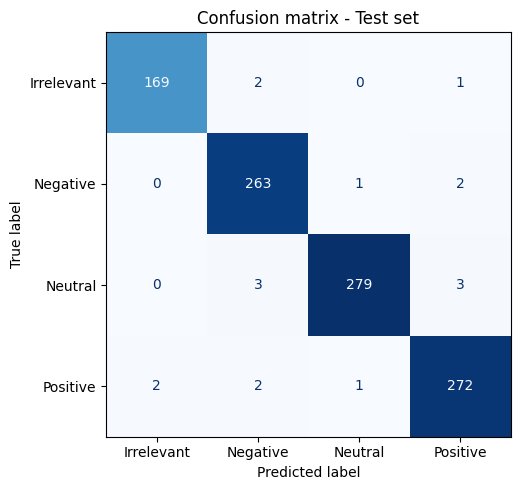

                 pred Irrelevant  pred Negative  pred Neutral  pred Positive
true Irrelevant              169              2             0              1
true Negative                  0            263             1              2
true Neutral                   0              3           279              3
true Positive                  2              2             1            272


In [91]:
# ============================================================================ #
#  חלק 5ד: מטריצת הבלבול                                                      #
# ============================================================================ #
labels = list(final_model.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(5.6, 5.0))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues",
                                                       colorbar=False, values_format="d")
ax.set_title("Confusion matrix - Test set")
ax.grid(False)
plt.tight_layout(); plt.show()

print(pd.DataFrame(cm,
                   index=[f"true {c}" for c in labels],
                   columns=[f"pred {c}" for c in labels]).to_string())

### למה הציון על ה-Test יצא גבוה מהערכת ה-Cross-Validation?

הציון על ה-Test יצא **גבוה** מהערכת ה-Cross-Validation, וזה מפתיע: בדרך כלל מצפים לכיוון ההפוך. במקום להניח הסבר, נבדוק אותו.

החשד נעוץ בדאטהסט עצמו: הוא בנוי כך שלכל ציוץ יש כמה ניסוחים חלופיים — הסתכלו שוב על חמש השורות הראשונות של ה-Train Set, כולן וריאציות של אותו משפט עם אותו `Tweet_ID` — וייתכן שחלק מהניסוחים האלה מופיעים גם בקובץ ה-Test. אם כך, המודל פשוט "זוכר" ציוצים שראה. התא הבא מפצל את ה-Test לשתי תת-קבוצות — ציוצים שמופיעים גם באימון וציוצים שלא — ומודד כל אחת בנפרד.

In [92]:
# ============================================================================ #
#  כמה מה-Test Set הוא בכלל ציוץ שהמודל כבר ראה באימון?                       #
# ============================================================================ #
def squash(s):
    """Identity key that ignores punctuation, spacing and case, so that two
    phrasings of the same tweet collapse onto the same string."""
    return re.sub(r"[^a-z0-9]", "", str(s).lower())


train_seen = {squash(t) for t in train_fit["Tweet_Text"]}
unseen = np.array([squash(t) not in train_seen for t in test_df["Tweet_Text"]])

print(f"{'subset':<46}{'n':>6}{'macro-F1':>11}")
print("-" * 63)
print(f"{'FULL test set (reported as the final metric)':<46}{len(y_test):>6}{macro_f1:>11.4f}")
print(f"{'  of which: also present in the training file':<46}{(~unseen).sum():>6}"
      f"{f1_score(y_test[~unseen], y_pred[~unseen], average='macro'):>11.4f}")
print(f"{'  of which: genuinely unseen tweets':<46}{unseen.sum():>6}"
      f"{f1_score(y_test[unseen], y_pred[unseen], average='macro'):>11.4f}")
print(f"\n  5-fold cross-validation estimate (Part 6a)  : {best['mean_macro_f1']:.4f}")

subset                                             n   macro-F1
---------------------------------------------------------------
FULL test set (reported as the final metric)    1000     0.9832
  of which: also present in the training file    716     0.9933
  of which: genuinely unseen tweets              284     0.9536

  5-fold cross-validation estimate (Part 6a)  : 0.9396


### מה הבדיקה מלמדת

החשד אושש. כ-72% מציוצי ה-Test (716 מתוך 1,000) מופיעים גם בקובץ ה-Training בניסוח כמעט זהה, והציון עליהם — 0.9933 — גבוה בבירור מהציון על הציוצים שהמודל לא ראה מעולם, 0.9536. זו תכונה של הדאטהסט עצמו כפי שפורסם ולא באג בפרוטוקול שלנו: ההנחיות אוסרות לחלק את הקבצים מחדש, ולכן אנחנו מדווחים את המדד הנדרש על כל ה-Test Set, ולצידו את הפילוח הכן.

**והנקודה החזקה באמת:** הציון על הציוצים החדשים לגמרי (0.9536) קרוב להערכת ה-Cross-Validation (0.9396) — הפרש של כ-0.014. שני אומדנים שחושבו בשתי דרכים שונות לחלוטין — אחד על ה-Train בחלוקה ל-Folds, השני על תת-קבוצה של ה-Test — נחתו כמעט על אותו מספר. זו העדות החזקה ביותר שיש לנו לכך שהפרוטוקול תקין ושאין דליפת מידע מהצד שלנו. הציון הרשמי של העבודה הוא זה שעל כל ה-Test Set, והמספר שמשקף את יכולת ההכללה האמיתית של המודל על ציוץ חדש הוא 0.9536.

## סיכום

| חלק | מה עשינו | התוצאה |
|---|---|---|
| 1 | טענו את שני הקבצים כפי שהם, בלי חלוקה מחדש; הצגנו את 5 השורות הראשונות של כל אחד | 74,682 שורות Train, 1,000 שורות Test |
| 2 | ניקוי סטייטלס (אותיות קטנות, הסרת קישורים ותיוגים, הרחבת שלילה מקוצרת, השארת אותיות בלבד), שרשור שם הישות לתחילת הטקסט הנקי, ואחריו ייצוג מספרי שמאומן על ה-Train בלבד | הוצג לפני/אחרי על 3 דוגמאות מכל סט |
| 3 | מימשנו Multinomial Naive Bayes מאפס במרחב לוגריתמי עם החלקת לפלס, ואימתנו מול `sklearn` | הפרש בסדר גודל של שגיאת עיגול ($10^{-15}$) |
| 6א | מכפלה קרטזית של 64 תצורות, כל אחת ב-5-Fold Cross Validation, על ה-Train בלבד | 320 אימונים; המנצחת: `tfidf`, `(1,2)`, אוצר מילים מלא, $\alpha=0.1$ — ציון 0.9396 |
| 4 | אימון מחדש של התצורה המנצחת על כל ה-Train, והצגת המסלול של 3 דוגמאות | 73,596 שורות, 284,607 מאפיינים |
| 5 | אותו preprocessing על ה-Test, 5 חיזויים ראשונים, Macro-F1, דוח סיווג ומטריצת בלבול | **Macro-F1 = 0.9832** (ועל ציוצים שלא נראו באימון: 0.9536) |

